# 08 — Causal Transformer GAN SDF

## Process
1. Load the same author firm panels (return + 46 ranked characteristics) and Code 05's 178 macro inputs. Check calendar alignment, padding, finite values, and training-only standardization.
2. Replace **both** macro LSTMs with causal Transformers: 4 SDF states and 32 adversarial states. Preserve the 64–64 SDF network, eight conditional instruments, raw-weight pricing moments, and gross-normalized evaluation.
3. Verify causality, prefix consistency, persistent-slot moment aggregation, gradient flow, and portfolio normalization.
4. Train matched LSTM and Transformer models on 1967–1986 only. Use 1987–1991 for validation reporting and 1992–2016 for final test reporting. No model, sign, seed, or hyperparameter is chosen using test results.
5. Average three fixed seeds, save checkpoints, training histories, performance, and a 600-month comparison series.
6. Answer the research questions using the executed results and provide the inputs for Codes 09 and 10.

## Questions
**Q1.** Can a causal Transformer produce the required macro states without using future months?

**Q2.** Does the Transformer improve test Sharpe relative to an LSTM trained with the same budget?

**Q3.** How stable are results across seeds, and how similar are the two ensemble factors?

**Q4.** What can these results establish, and what do Codes 09 and 10 investigate next?

## Experimental scope
This is a **matched-budget extension**, with seeds 42–44 and 64/16/128 epochs for unconditional SDF / adversary / conditional SDF. Both architectures use Adam at 0.001 and the final stage checkpoint, with no early stopping. The final adversary is used in both arms. Code 06 used nine seeds and 256/64/1024 epochs with its strongest-adversary rule; its saved result is shown separately as a historical reference and is **not** the controlled comparison. This initial budget is declared before examining the test sample. Additional trials must not be tuned to test Sharpe.

The Transformer has two attention layers, four heads, 32 internal dimensions, 64 feedforward dimensions, sinusoidal positions, and a strictly causal mask. Different parameter counts are inherent to the architecture comparison. It retains all available macro history; evaluation starts in January 1967 and never resets at a split boundary.

Causality checks verify computation, not real-time availability of the underlying macro releases or revisions. The author inputs are used with the timing supplied in the existing replication; no new claim of vintage-safe data is made. Returns retain the same author return convention as Code 06. Reported Sharpe is mean factor return divided by sample volatility, with no additional risk-free subtraction.


## 1 — Environment, paths, and fixed configuration

In [1]:
from pathlib import Path
import sys, json, time, hashlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def find_root():
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "notebooks" / "06_GAN.ipynb").exists() and (p / "results").exists():
            return p
    raise FileNotFoundError("Start Jupyter inside the replication repository.")

ROOT = find_root()
sys.path.insert(0, str(ROOT / "src" / "models"))
from transformer_gan import (GAN, CausalTransformerEncoder, MacroLSTMEncoder,
    SPLITS, load_panel, pricing_loss, factor_and_scores, train_member, evaluate,
    seed_all, stats, fingerprint_files)

CONFIG = {"seeds": [42, 43, 44], "epochs": [64, 16, 128], "learning_rate": 0.001,
    "sdf_hidden": [64, 64], "sdf_macro_dim": 4, "conditional_macro_dim": 32,
    "macro_features": 178, "firm_features": 46, "instruments": 8,
    "dropout": 0.05, "transformer_d_model": 32, "transformer_heads": 4,
    "transformer_layers": 2, "transformer_feedforward": 64,
    "adversary_selection": "final", "sdf_selection": "final", "device": "cpu"}
# CPU avoids device-dependent scatter behavior; all seeds use the same device.
DEVICE = torch.device(CONFIG["device"])
torch.set_num_threads(6)
EXPERIMENT = ROOT / "results" / "transformer_extension"
for name in ["models", "tables", "factors", "figures"]:
    (EXPERIMENT / name).mkdir(parents=True, exist_ok=True)
DATES = pd.date_range("1967-01-01", "2016-12-01", freq="MS")
LABELS = np.array(["train"]*240 + ["validation"]*60 + ["test"]*300)
print("Repository:", ROOT)
print("Experiment:", EXPERIMENT)
print(json.dumps(CONFIG, indent=2))


Repository: /Users/reza/Desktop/mfe-term_3/deep_learning1/Deep-Learning-in-Asset-Pricing_-Replication-project
Experiment: /Users/reza/Desktop/mfe-term_3/deep_learning1/Deep-Learning-in-Asset-Pricing_-Replication-project/results/transformer_extension
{
  "seeds": [
    42,
    43,
    44
  ],
  "epochs": [
    64,
    16,
    128
  ],
  "learning_rate": 0.001,
  "sdf_hidden": [
    64,
    64
  ],
  "sdf_macro_dim": 4,
  "conditional_macro_dim": 32,
  "macro_features": 178,
  "firm_features": 46,
  "instruments": 8,
  "dropout": 0.05,
  "transformer_d_model": 32,
  "transformer_heads": 4,
  "transformer_layers": 2,
  "transformer_feedforward": 64,
  "adversary_selection": "final",
  "sdf_selection": "final",
  "device": "cpu"
}


## 2 — Load and validate the existing replication inputs
The author datasets remain in their original local folder. Set `DATASETS_ROOT` explicitly if you move them. Only active slots are compressed; each observation retains its original persistent asset-slot index.

In [2]:
DATASETS_ROOT = None
candidates = [ROOT / "datasets", ROOT.parent / "datasets", ROOT.parent / "project " / "datasets"]
if DATASETS_ROOT is None:
    DATASETS_ROOT = next((p for p in candidates if (p / "char" / "Char_train.npz").exists()), None)
if DATASETS_ROOT is None:
    raise FileNotFoundError("Set DATASETS_ROOT to the author datasets folder containing char/Char_train.npz.")
MACRO_PATH = ROOT / "results" / "macro" / "macro_lstm_input.parquet"
macro_df = pd.read_parquet(MACRO_PATH).sort_values("date").reset_index(drop=True)
macro_df["date"] = pd.to_datetime(macro_df["date"]).dt.to_period("M").dt.to_timestamp()
macro_cols = [x for x in macro_df.columns if x != "date"]
assert len(macro_cols) == 178
assert pd.DatetimeIndex(macro_df["date"]).equals(DATES)
macro_np = macro_df[macro_cols].to_numpy(dtype=np.float32)
assert np.isfinite(macro_np).all()
# Code 05 already standardized with training statistics; do not standardize twice.
assert np.allclose(macro_np[:240].mean(0), 0, atol=2e-5)
assert np.allclose(macro_np[:240].std(0, ddof=0), 1, atol=2e-5)
macro = torch.tensor(macro_np, device=DEVICE).unsqueeze(0)
filenames = {"train": "Char_train.npz", "validation": "Char_valid.npz", "test": "Char_test.npz"}
panels = {}
for split, (start, end) in SPLITS.items():
    panels[split] = load_panel(DATASETS_ROOT / "char" / filenames[split], DATES[start:end], DEVICE)
assert panels["train"]["names"] == panels["validation"]["names"] == panels["test"]["names"]
inventory = pd.DataFrame([{"split": s, "months": p["T"], "slots": p["N"],
    "active_stock_months": len(p["r"]), "start": p["dates"].min(), "end": p["dates"].max()} for s,p in panels.items()])
display(inventory)
inventory.to_csv(EXPERIMENT / "tables" / "input_inventory.csv", index=False)
fingerprint = fingerprint_files([MACRO_PATH, *[DATASETS_ROOT / "char" / f for f in filenames.values()],
    ROOT / "src" / "models" / "transformer_gan.py"])
manifest = {"config": CONFIG, "inputs": fingerprint, "python": sys.version, "torch": torch.__version__, "numpy": np.__version__, "pandas": pd.__version__}
(EXPERIMENT / "manifest.json").write_text(json.dumps(manifest, indent=2))


,split,months,slots,active_stock_months,start,end
0,train,240,3686,336113,1967-01-01,1986-12-01
1,validation,60,3347,132167,1987-01-01,1991-12-01
2,test,300,7141,750275,1992-01-01,2016-12-01


1630

## 3 — Architecture and meaningful integrity tests
Future-value perturbations and prefix checks run in evaluation mode so dropout cannot obscure causality. A small unbalanced panel verifies that vectorized moments equal explicit per-asset averages, including an inactive slot.

In [3]:
seed_all(42)
checks = []
for kind in ["LSTM", "Transformer"]:
    model = GAN(kind).to(DEVICE).eval()
    print(kind, "parameters:", sum(p.numel() for p in model.parameters()))
    for name, dim in [("sdf_macro_encoder", 4), ("cond_macro_encoder", 32)]:
        encoder = getattr(model, name)
        z = macro.clone(); z[:, 300:] += 100*torch.randn_like(z[:, 300:])
        with torch.no_grad():
            original = encoder(macro); changed = encoder(z); prefix = encoder(macro[:, :300])
        assert original.shape == (1,600,dim)
        torch.testing.assert_close(original[:, :300], changed[:, :300], rtol=1e-5, atol=2e-6)
        torch.testing.assert_close(original[:, :300], prefix, rtol=1e-5, atol=2e-6)
        checks.append({"architecture": kind, "check": name + " causal/prefix", "passed": True})
    # Full objective equivalence on an unbalanced toy panel with original slot IDs.
    toy = {"T": 3, "N": 4, "x": torch.randn(5,46)*.1,
        "r": torch.tensor([.02,-.01,.03,-.04,.01]), "month": torch.tensor([0,0,1,2,2]),
        "slot": torch.tensor([0,2,0,1,2]), "counts": torch.tensor([2.,1.,2.,0.])}
    for conditional in [False,True]:
        sm = model.sdf_macro_encoder(macro[:,:3])[0]
        cm = model.cond_macro_encoder(macro[:,:3])[0]
        raw, gross, w = factor_and_scores(model,toy,sm)
        g = model.conditional_network(toy["x"],cm[toy["month"]]) if conditional else torch.ones(5,1)
        values = ((1-raw[toy["month"]])*toy["r"])[:,None]*g
        reference = torch.stack([(toy["counts"][j]/3)*(values[toy["slot"]==j].mean(0).square().sum()) for j in [0,1,2]]).mean()
        actual = pricing_loss(model,toy,macro[:,:3],conditional)
        torch.testing.assert_close(actual, reference)
        model.zero_grad(set_to_none=True); actual.backward()
        for component in ([model.sdf_macro_encoder,model.sdf_network,model.cond_macro_encoder,model.conditional_network] if conditional else [model.sdf_macro_encoder,model.sdf_network]):
            assert any(p.grad is not None and torch.isfinite(p.grad).all() and p.grad.abs().sum()>0 for p in component.parameters())
        normalized_gross = torch.zeros(3).index_add(0,toy["month"],(w/gross[toy["month"]]).abs())
        torch.testing.assert_close(normalized_gross, torch.ones(3))
        checks.append({"architecture": kind, "check": "conditional" if conditional else "unconditional", "passed": True})
integrity = pd.DataFrame(checks)
display(integrity)
integrity.to_csv(EXPERIMENT / "tables" / "architecture_integrity.csv", index=False)
del model
print("All causality, prefix, moment, gradient, and gross-normalization tests passed.")


LSTM parameters: 38201


Transformer parameters: 54941


,architecture,check,passed
0,LSTM,sdf_macro_encoder causal/prefix,True
1,LSTM,cond_macro_encoder causal/prefix,True
2,LSTM,unconditional,True
3,LSTM,conditional,True
4,Transformer,sdf_macro_encoder causal/prefix,True
5,Transformer,cond_macro_encoder causal/prefix,True
6,Transformer,unconditional,True
7,Transformer,conditional,True


All causality, prefix, moment, gradient, and gross-normalization tests passed.


## 4 — Joint GAN estimation
The macro encoders are trained jointly with pricing networks. Stage 1 minimizes unconditional moments; Stage 2 freezes the SDF and maximizes conditional moments; Stage 3 freezes the adversary and minimizes conditional moments. Frozen outputs are cached within each stage. Every epoch uses all active training observations and original asset-slot counts. Checkpoint reuse requires the same configuration and SHA-256 input/source hashes; validation and test data never enter optimizer updates.

In [4]:
members = {}; history_parts = []; member_rows = []
started = time.monotonic()
for kind in ["LSTM", "Transformer"]:
    factors = []
    for seed in CONFIG["seeds"]:
        model, history = train_member(kind, seed, panels["train"], macro[:,:240],
            CONFIG, EXPERIMENT / "models", fingerprint)
        factor = evaluate(model, panels, macro)
        assert factor.shape == (600,) and np.isfinite(factor).all()
        # Serialized checkpoints must reproduce evaluated returns.
        restored = GAN(kind).to(DEVICE)
        saved = torch.load(EXPERIMENT / "models" / f"{kind.lower()}_seed_{seed}.pt", map_location=DEVICE, weights_only=False)
        restored.load_state_dict(saved["state_dict"])
        np.testing.assert_allclose(evaluate(restored, panels, macro), factor, rtol=1e-5, atol=1e-7)
        factors.append(factor); history_parts.append(history)
        for split,(a,b) in SPLITS.items():
            member_rows.append({"architecture": kind, "seed": seed, "split": split, **stats(factor[a:b])})
        pd.DataFrame({"date": DATES, "split": LABELS, "factor_return": factor}).to_csv(
            EXPERIMENT / "factors" / f"{kind.lower()}_seed_{seed}.csv", index=False)
        del model, restored
    members[kind] = np.column_stack(factors)
member_performance = pd.DataFrame(member_rows)
history = pd.concat(history_parts, ignore_index=True)
member_performance.to_csv(EXPERIMENT / "tables" / "member_performance.csv", index=False)
history.to_csv(EXPERIMENT / "tables" / "training_history.csv", index=False)
print(f"All six GAN models completed in {(time.monotonic()-started)/60:.1f} minutes.")
display(member_performance)


LSTM seed=42 stage=1 epoch=1/64 loss=0.28116354 elapsed=0.4s


LSTM seed=42 stage=1 epoch=16/64 loss=0.02435334 elapsed=2.6s


LSTM seed=42 stage=1 epoch=32/64 loss=0.00404575 elapsed=4.9s


LSTM seed=42 stage=1 epoch=48/64 loss=0.00072367152 elapsed=7.2s


LSTM seed=42 stage=1 epoch=64/64 loss=0.0001959974 elapsed=9.6s


...

Transformer seed=44 stage=3 epoch=96/128 loss=0.00016123228 elapsed=24.9s


Transformer seed=44 stage=3 epoch=112/128 loss=0.00015152898 elapsed=27.4s


Transformer seed=44 stage=3 epoch=128/128 loss=0.00013195281 elapsed=29.8s


All six GAN models completed in 3.0 minutes.


,architecture,seed,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,LSTM,42,train,240,0.011852,0.012645,0.937275,3.246816,-0.027635,0.061248,0.862500
1,LSTM,42,validation,60,0.007071,0.011728,0.602962,2.088723,-0.022871,0.033311,0.750000
2,LSTM,42,test,300,0.004235,0.020431,0.207308,0.718137,-0.094755,0.105902,0.663333
3,LSTM,43,train,240,0.012183,0.012900,0.944357,3.271350,-0.026014,0.064301,0.862500
4,LSTM,43,validation,60,0.004018,0.013514,0.297281,1.029813,-0.067866,0.024859,0.683333
5,LSTM,43,test,300,0.003421,0.014985,0.228301,0.790859,-0.080983,0.047581,0.630000
6,LSTM,44,train,240,0.013314,0.013208,1.008020,3.491885,-0.040898,0.058906,0.862500
7,LSTM,44,validation,60,0.004140,0.019000,0.217900,0.754827,-0.082275,0.038871,0.716667
8,LSTM,44,test,300,0.005878,0.018762,0.313276,1.085221,-0.080849,0.068189,0.710000
9,Transformer,42,train,240,0.017030,0.015046,1.131827,3.920765,-0.033679,0.074024,0.883333


## 5 — Ensemble performance and comparison
Equal-weight averaging uses every predetermined seed. Compare the matched ensembles first. The Code 07 LSTM ensemble is a separately labelled reference with a larger budget. Annualized Sharpe uses √12; this scaling does not adjust for serial correlation.

In [5]:
ensembles = {kind: values.mean(axis=1) for kind,values in members.items()}
reference = pd.read_csv(ROOT / "results" / "factors" / "gan_ensemble_sdf.csv")
reference["date"] = pd.to_datetime(reference["date"]).dt.to_period("M").dt.to_timestamp()
reference = reference.sort_values("date")
assert pd.DatetimeIndex(reference["date"]).equals(DATES)
comparison = pd.DataFrame({"date": DATES, "split": LABELS,
    "gan_lstm_matched": ensembles["LSTM"], "gan_transformer": ensembles["Transformer"],
    "gan_lstm_code07_reference": reference["gan_ensemble_sdf"].to_numpy()})
performance_rows = []
for name in ["gan_lstm_matched", "gan_transformer", "gan_lstm_code07_reference"]:
    for split,(a,b) in SPLITS.items():
        performance_rows.append({"model": name, "split": split, **stats(comparison[name].iloc[a:b])})
performance = pd.DataFrame(performance_rows)
display(performance)
performance.to_csv(EXPERIMENT / "tables" / "ensemble_performance.csv", index=False)
comparison.to_csv(EXPERIMENT / "factors" / "transformer_lstm_comparison.csv", index=False)
pd.DataFrame({"date": DATES, "split": LABELS, "gan_transformer_sdf": ensembles["Transformer"]}).to_csv(
    ROOT / "results" / "factors" / "gan_transformer_sdf.csv", index=False)
correlations = pd.DataFrame([{ "split": split, "lstm_transformer_correlation":
    comparison.iloc[a:b][["gan_lstm_matched","gan_transformer"]].corr().iloc[0,1] } for split,(a,b) in SPLITS.items()])
display(correlations)
correlations.to_csv(EXPERIMENT / "tables" / "factor_correlations.csv", index=False)
stability = member_performance.groupby(["architecture","split"])["monthly_sharpe"].agg(["mean","std","min","max"]).reset_index()
display(stability)
stability.to_csv(EXPERIMENT / "tables" / "seed_stability.csv", index=False)


,model,split,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,gan_lstm_matched,train,240,0.012449,0.010303,1.208332,4.185784,-0.015418,0.049431,0.920833
1,gan_lstm_matched,validation,60,0.005076,0.012096,0.419683,1.453823,-0.057671,0.029086,0.733333
2,gan_lstm_matched,test,300,0.004511,0.014491,0.311336,1.078499,-0.074662,0.060986,0.696667
3,gan_transformer,train,240,0.015887,0.012376,1.283717,4.446926,-0.024110,0.052858,0.912500
4,gan_transformer,validation,60,0.008416,0.012918,0.651473,2.256768,-0.018403,0.053526,0.750000
5,gan_transformer,test,300,0.006112,0.013847,0.441400,1.529056,-0.075901,0.066437,0.760000
6,gan_lstm_code07_reference,train,240,0.017087,0.007701,2.218878,7.686419,-0.000954,0.043305,0.991667
7,gan_lstm_code07_reference,validation,60,0.009048,0.007697,1.175489,4.072014,-0.005756,0.031570,0.850000
8,gan_lstm_code07_reference,test,300,0.006997,0.011454,0.610867,2.116105,-0.051845,0.067200,0.823333


,split,lstm_transformer_correlation
0,train,0.719203
1,validation,0.319473
2,test,0.579929


,architecture,split,mean,std,min,max
0,LSTM,test,0.249629,0.056111,0.207308,0.313276
1,LSTM,train,0.963218,0.038962,0.937275,1.008020
2,LSTM,validation,0.372715,0.203312,0.217900,0.602962
3,Transformer,test,0.366107,0.050342,0.321611,0.420749
4,Transformer,train,1.102971,0.025228,1.085088,1.131827
5,Transformer,validation,0.457586,0.119876,0.338562,0.578296


## 6 — Training and test-period figures
Cumulative sums below are diagnostic cumulative factor returns, not compounded wealth. Codes 09–10 will examine rolling risk and regime dependence.

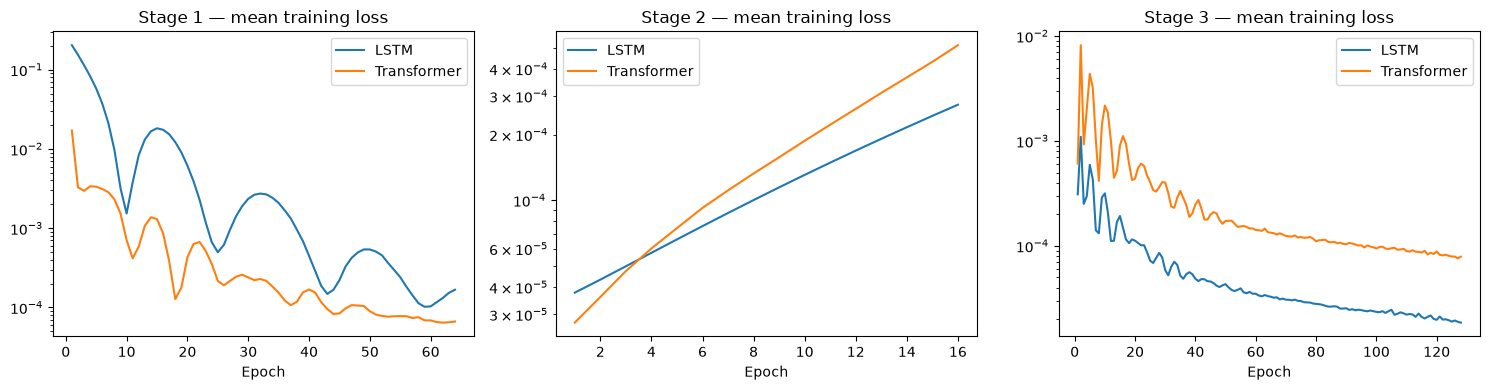

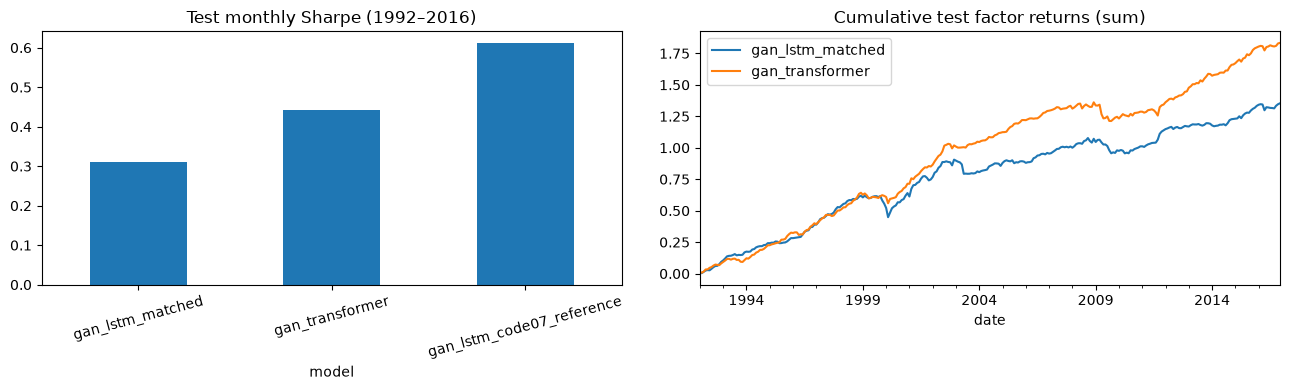

In [6]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
for stage,ax in enumerate(axes,1):
    for kind in ["LSTM","Transformer"]:
        mean = history[(history.stage==stage)&(history.architecture==kind)].groupby("epoch")["loss"].mean()
        ax.plot(mean.index,mean,label=kind)
    ax.set_title(f"Stage {stage} — mean training loss"); ax.set_yscale("log"); ax.set_xlabel("Epoch"); ax.legend()
fig.tight_layout(); fig.savefig(EXPERIMENT / "figures" / "training_losses.png", dpi=150); plt.show()
fig,axes = plt.subplots(1,2,figsize=(13,4))
performance[performance.split=="test"].set_index("model")["monthly_sharpe"].plot.bar(ax=axes[0],rot=15)
axes[0].set_title("Test monthly Sharpe (1992–2016)")
test = comparison[comparison.split=="test"].set_index("date")
test[["gan_lstm_matched","gan_transformer"]].cumsum().plot(ax=axes[1])
axes[1].set_title("Cumulative test factor returns (sum)")
fig.tight_layout();fig.savefig(EXPERIMENT / "figures" / "test_comparison.png",dpi=150);plt.show()


## 7 — Results, answers, and relationship to Codes 09–10
The following cell generates the conclusions directly from this run. It does not assume that the Transformer wins.

In [7]:
test_stats = performance[performance.split=="test"].set_index("model")
lstm_sr = test_stats.loc["gan_lstm_matched","monthly_sharpe"]
transformer_sr = test_stats.loc["gan_transformer","monthly_sharpe"]
difference = transformer_sr-lstm_sr
corr = correlations.loc[correlations.split=="test","lstm_transformer_correlation"].iloc[0]
seed_ranges = stability[stability.split=="test"].set_index("architecture")
direction = "higher" if difference>0 else "lower" if difference<0 else "equal"
summary = f"""### Executed results
The matched LSTM ensemble has **{lstm_sr:.4f}** test monthly Sharpe; the Transformer ensemble has **{transformer_sr:.4f}**. The Transformer is {direction} by **{abs(difference):.4f}** in this fixed-budget run. The larger Code 07 reference has **{test_stats.loc['gan_lstm_code07_reference','monthly_sharpe']:.4f}**.

**Q1 — Causal state construction:** Passed. Both Transformer encoders return the required 4/32-dimensional states. Future perturbations do not affect earlier states, and full-sequence outputs agree with prefix-only outputs. The objective, gradient, normalization, calendar, and checkpoint reload checks also passed.

**Q2 — Performance:** The Transformer is {direction} on the untouched 1992–2016 test period for this experiment. This is an observed comparison, not a statistical significance claim or evidence that either architecture always wins. No test-based tuning or seed selection was performed.

**Q3 — Stability and similarity:** Test correlation is **{corr:.4f}**. Individual LSTM seed Sharpes range from **{seed_ranges.loc['LSTM','min']:.4f}** to **{seed_ranges.loc['LSTM','max']:.4f}**; Transformer seeds range from **{seed_ranges.loc['Transformer','min']:.4f}** to **{seed_ranges.loc['Transformer','max']:.4f}**. Three seeds give an initial sensitivity check, not a confidence interval. The saved member table reports every seed.

**Q4 — Interpretation and next codes:** This run isolates the macro encoder architecture under a matched budget and validates the end-to-end pricing pipeline. It does not reproduce the full nine-seed training schedule or prove real-time macro-data availability. Code **09** will read `transformer_lstm_comparison.csv`, keep only `split == 'test'`, and compare 36/60-month rolling Sharpe and volatility, cumulative performance, drawdowns, and correlations. Code **10** will use the same test returns for recession/expansion and volatility regimes. Use a training-calibrated volatility threshold and lagged market volatility for prospective labels; NBER recession labels are retrospective descriptive labels. Do not optimize models or regime thresholds on test performance.

The primary pair for Codes 09–10 is `gan_lstm_matched` versus `gan_transformer`. The `gan_lstm_code07_reference` column is optional and must retain its different-budget label. Dates are month starts; returns use decimal units; each model has 240 train, 60 validation, and 300 test observations. Preserve the same return definition and gross-normalization convention across all three notebooks.
"""
display(Markdown(summary))
(EXPERIMENT / "results_and_answers.txt").write_text(summary)
assert len(comparison)==600 and not comparison.date.duplicated().any()
assert np.isfinite(comparison.select_dtypes(include="number").to_numpy()).all()
assert integrity.passed.all()
assert len(member_performance)==18 and len(performance)==9
assert len(list((EXPERIMENT / "models").glob("*.pt"))) == 6
print("CODE 08 COMPLETE: trained models, executed answers, tables, figures, and monthly factors saved.")


### Executed results
The matched LSTM ensemble has **0.3113** test monthly Sharpe; the Transformer ensemble has **0.4414**. The Transformer is higher by **0.1301** in this fixed-budget run. The larger Code 07 reference has **0.6109**.

**Q1 — Causal state construction:** Passed. Both Transformer encoders return the required 4/32-dimensional states. Future perturbations do not affect earlier states, and full-sequence outputs agree with prefix-only outputs. The objective, gradient, normalization, calendar, and checkpoint reload checks also passed.

**Q2 — Performance:** The Transformer is higher on the untouched 1992–2016 test period for this experiment. This is an observed comparison, not a statistical significance claim or evidence that either architecture always wins. No test-based tuning or seed selection was performed.

**Q3 — Stability and similarity:** Test correlation is **0.5799**. Individual LSTM seed Sharpes range from **0.2073** to **0.3133**; Transformer seeds range from **0.3216** to **0.4207**. Three seeds give an initial sensitivity check, not a confidence interval. The saved member table reports every seed.

**Q4 — Interpretation and next codes:** This run isolates the macro encoder architecture under a matched budget and validates the end-to-end pricing pipeline. It does not reproduce the full nine-seed training schedule or prove real-time macro-data availability. Code **09** will read `transformer_lstm_comparison.csv`, keep only `split == 'test'`, and compare 36/60-month rolling Sharpe and volatility, cumulative performance, drawdowns, and correlations. Code **10** will use the same test returns for recession/expansion and volatility regimes. Use a training-calibrated volatility threshold and lagged market volatility for prospective labels; NBER recession labels are retrospective descriptive labels. Do not optimize models or regime thresholds on test performance.

The primary pair for Codes 09–10 is `gan_lstm_matched` versus `gan_transformer`. The `gan_lstm_code07_reference` column is optional and must retain its different-budget label. Dates are month starts; returns use decimal units; each model has 240 train, 60 validation, and 300 test observations. Preserve the same return definition and gross-normalization convention across all three notebooks.


CODE 08 COMPLETE: trained models, executed answers, tables, figures, and monthly factors saved.


### Executed results
The matched LSTM ensemble has **0.3113** test monthly Sharpe; the Transformer ensemble has **0.4414**. The Transformer is higher by **0.1301** in this fixed-budget run. The larger Code 07 reference has **0.6109**.

**Q1 — Causal state construction:** Passed. Both Transformer encoders return the required 4/32-dimensional states. Future perturbations do not affect earlier states, and full-sequence outputs agree with prefix-only outputs. The objective, gradient, normalization, calendar, and checkpoint reload checks also passed.

**Q2 — Performance:** The Transformer is higher on the untouched 1992–2016 test period for this experiment. This is an observed comparison, not a statistical significance claim or evidence that either architecture always wins. No test-based tuning or seed selection was performed.

**Q3 — Stability and similarity:** Test correlation is **0.5799**. Individual LSTM seed Sharpes range from **0.2073** to **0.3133**; Transformer seeds range from **0.3216** to **0.4207**. Three seeds give an initial sensitivity check, not a confidence interval. The saved member table reports every seed.

**Q4 — Interpretation and next codes:** This run isolates the macro encoder architecture under a matched budget and validates the end-to-end pricing pipeline. It does not reproduce the full nine-seed training schedule or prove real-time macro-data availability. Code **09** will read `transformer_lstm_comparison.csv`, keep only `split == 'test'`, and compare 36/60-month rolling Sharpe and volatility, cumulative performance, drawdowns, and correlations. Code **10** will use the same test returns for recession/expansion and volatility regimes. Use a training-calibrated volatility threshold and lagged market volatility for prospective labels; NBER recession labels are retrospective descriptive labels. Do not optimize models or regime thresholds on test performance.

The primary pair for Codes 09–10 is `gan_lstm_matched` versus `gan_transformer`. The `gan_lstm_code07_reference` column is optional and must retain its different-budget label. Dates are month starts; returns use decimal units; each model has 240 train, 60 validation, and 300 test observations. Preserve the same return definition and gross-normalization convention across all three notebooks.
